<a href="https://colab.research.google.com/github/infant88/Big_Data_Pipeline_Hadoop_Hive/blob/main/Big_Data_Pipeline_Hadoop_Hive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐘 Big Data Pipeline with Hadoop and Hive

**Course:** 22CSEDE23 – Big Data Analytics  
**Mini Project 1** | Department of CSE  
**Year/Sem/Section:** III / VI / B

---

## 📌 Objective
Build a Big Data Pipeline that:
1. **Collects** data from multiple sources (logs, sensors, social media)
2. **Stores** data in HDFS (simulated)
3. **Processes** data using Hive (via PyHive / SQLite simulation)
4. **Visualizes** results using Matplotlib & Seaborn (Tableau/Power BI equivalent)

---

## 🏗️ Architecture Overview
```
Data Sources          Ingestion Layer        Storage Layer        Processing Layer      Visualization
─────────────         ───────────────        ─────────────        ────────────────      ─────────────
Web Server Logs  ──►                                                                    
IoT Sensor Data  ──►  Python Scripts   ──►   HDFS (simulated) ──►  Hive (SQL)      ──►  Matplotlib
Social Media API ──►                                                                    Seaborn
```

## 🔧 Step 1: Install Required Libraries

In [1]:
# Install required packages
!pip install faker pandas matplotlib seaborn plotly --quiet
print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.4 MB/s eta 0:00:00
✅ All packages installed successfully!


## 📦 Step 2: Import Libraries

In [2]:
import os
import json
import random
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from faker import Faker
from datetime import datetime, timedelta
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
fake = Faker()
random.seed(42)
np.random.seed(42)

# Simulate HDFS as local directory structure
HDFS_ROOT = "/tmp/hdfs_simulation"
os.makedirs(f"{HDFS_ROOT}/logs",    exist_ok=True)
os.makedirs(f"{HDFS_ROOT}/sensors", exist_ok=True)
os.makedirs(f"{HDFS_ROOT}/social",  exist_ok=True)

print("✅ Libraries imported successfully!")
print(f"📁 HDFS Root Directory: {HDFS_ROOT}")
print(f"   ├── {HDFS_ROOT}/logs")
print(f"   ├── {HDFS_ROOT}/sensors")
print(f"   └── {HDFS_ROOT}/social")

✅ Libraries imported successfully!
📁 HDFS Root Directory: /tmp/hdfs_simulation
   ├── /tmp/hdfs_simulation/logs
   ├── /tmp/hdfs_simulation/sensors
   └── /tmp/hdfs_simulation/social


## 🌐 Step 3: Data Collection from Multiple Sources

### 3.1 Source 1 — Web Server Logs

In [3]:
def generate_web_logs(n=500):
    """Generate synthetic Apache-style web server logs."""
    methods    = ["GET", "POST", "PUT", "DELETE"]
    endpoints  = ["/home", "/login", "/products", "/api/data", "/checkout", "/search"]
    status_codes = [200, 200, 200, 301, 400, 404, 500]

    records = []
    base_time = datetime(2024, 1, 1)

    for i in range(n):
        timestamp   = base_time + timedelta(minutes=random.randint(0, 43200))
        ip_address  = fake.ipv4()
        method      = random.choice(methods)
        endpoint    = random.choice(endpoints)
        status_code = random.choice(status_codes)
        response_time_ms = random.randint(50, 3000)
        bytes_sent  = random.randint(512, 102400)

        records.append({
            "timestamp":        timestamp.strftime("%Y-%m-%d %H:%M:%S"),
            "ip_address":       ip_address,
            "method":           method,
            "endpoint":         endpoint,
            "status_code":      status_code,
            "response_time_ms": response_time_ms,
            "bytes_sent":       bytes_sent
        })

    return pd.DataFrame(records)

logs_df = generate_web_logs(500)

# Save to simulated HDFS
log_path = f"{HDFS_ROOT}/logs/web_server_logs.csv"
logs_df.to_csv(log_path, index=False)

print(f"✅ Web Server Logs generated: {len(logs_df)} records")
print(f"📁 Stored in HDFS: {log_path}\n")
display(logs_df.head(5))

✅ Web Server Logs generated: 500 records
📁 Stored in HDFS: /tmp/hdfs_simulation/logs/web_server_logs.csv



,timestamp,ip_address,method,endpoint,status_code,response_time_ms,bytes_sent
0,2024-01-30 02:25:00,12.215.59.119,GET,/home,404,1176,32610
1,2024-01-11 03:48:00,6.128.233.223,POST,/search,200,2821,97592
2,2024-01-25 19:41:00,55.223.66.255,GET,/checkout,301,180,4417
3,2024-01-05 06:20:00,43.175.167.111,POST,/login,400,2515,3990
4,2024-01-26 13:01:00,1.113.9.26,POST,/search,404,2922,71938


### 3.2 Source 2 — IoT Sensor Data

In [4]:
def generate_sensor_data(n=400):
    """Generate synthetic IoT sensor readings."""
    sensor_ids = [f"SENSOR_{i:03d}" for i in range(1, 11)]
    locations  = ["Factory_Floor", "Warehouse_A", "Warehouse_B", "Office", "Rooftop"]

    records = []
    base_time = datetime(2024, 1, 1)

    for i in range(n):
        sensor_id   = random.choice(sensor_ids)
        location    = random.choice(locations)
        timestamp   = base_time + timedelta(minutes=random.randint(0, 43200))
        temperature = round(random.uniform(15.0, 85.0), 2)
        humidity    = round(random.uniform(20.0, 95.0), 2)
        pressure    = round(random.uniform(950.0, 1050.0), 2)
        vibration   = round(random.uniform(0.0, 10.0), 3)
        status      = "NORMAL" if temperature < 70 else "ALERT"

        records.append({
            "timestamp":   timestamp.strftime("%Y-%m-%d %H:%M:%S"),
            "sensor_id":   sensor_id,
            "location":    location,
            "temperature": temperature,
            "humidity":    humidity,
            "pressure":    pressure,
            "vibration":   vibration,
            "status":      status
        })

    return pd.DataFrame(records)

sensors_df = generate_sensor_data(400)

# Save to simulated HDFS
sensor_path = f"{HDFS_ROOT}/sensors/iot_sensor_data.csv"
sensors_df.to_csv(sensor_path, index=False)

print(f"✅ IoT Sensor Data generated: {len(sensors_df)} records")
print(f"📁 Stored in HDFS: {sensor_path}\n")
display(sensors_df.head(5))

✅ IoT Sensor Data generated: 400 records
📁 Stored in HDFS: /tmp/hdfs_simulation/sensors/iot_sensor_data.csv



,timestamp,sensor_id,location,temperature,humidity,pressure,vibration,status
0,2024-01-03 13:17:00,SENSOR_009,Office,59.57,72.71,958.27,8.453,NORMAL
1,2024-01-05 08:09:00,SENSOR_006,Rooftop,77.64,88.94,972.98,9.013,ALERT
2,2024-01-13 08:06:00,SENSOR_010,Office,18.26,25.58,1042.56,8.993,NORMAL
3,2024-01-09 03:54:00,SENSOR_010,Factory_Floor,80.01,43.59,1046.15,5.870,ALERT
4,2024-01-14 14:53:00,SENSOR_007,Factory_Floor,26.37,38.04,1033.47,3.892,NORMAL


### 3.3 Source 3 — Social Media API Data

In [5]:
def generate_social_media_data(n=300):
    """Generate synthetic social media post data (Twitter/X API style)."""
    topics     = ["BigData", "AI", "MachineLearning", "Cloud", "IoT", "Hadoop", "Python"]
    sentiments = ["positive", "negative", "neutral"]
    platforms  = ["Twitter", "Reddit", "LinkedIn"]

    records = []
    base_time = datetime(2024, 1, 1)

    for i in range(n):
        timestamp   = base_time + timedelta(minutes=random.randint(0, 43200))
        topic       = random.choice(topics)
        sentiment   = random.choice(sentiments)
        platform    = random.choice(platforms)
        likes       = random.randint(0, 5000)
        retweets    = random.randint(0, 1000)
        followers   = random.randint(10, 500000)

        records.append({
            "timestamp":  timestamp.strftime("%Y-%m-%d %H:%M:%S"),
            "user_id":    fake.uuid4()[:8],
            "platform":   platform,
            "topic":      topic,
            "sentiment":  sentiment,
            "likes":      likes,
            "retweets":   retweets,
            "followers":  followers
        })

    return pd.DataFrame(records)

social_df = generate_social_media_data(300)

# Save to simulated HDFS
social_path = f"{HDFS_ROOT}/social/social_media_data.csv"
social_df.to_csv(social_path, index=False)

print(f"✅ Social Media Data generated: {len(social_df)} records")
print(f"📁 Stored in HDFS: {social_path}\n")
display(social_df.head(5))

✅ Social Media Data generated: 300 records
📁 Stored in HDFS: /tmp/hdfs_simulation/social/social_media_data.csv



,timestamp,user_id,platform,topic,sentiment,likes,retweets,followers
0,2024-01-14 20:56:00,f245cea2,LinkedIn,AI,negative,3622,638,76460
1,2024-01-21 01:06:00,d4eb838a,Twitter,BigData,positive,3062,159,397280
2,2024-01-04 21:43:00,e26ff4e6,Twitter,BigData,neutral,1991,971,325594
3,2024-01-07 17:18:00,f5ed7bc6,Twitter,Python,negative,2812,710,421684
4,2024-01-06 01:32:00,dd9f69bc,Reddit,MachineLearning,negative,186,339,109591


## 🗄️ Step 4: HDFS Storage Simulation

Demonstrating HDFS commands and storage structure.

In [6]:
def simulate_hdfs_commands():
    """Simulate HDFS shell commands for demonstration."""
    print("="*60)
    print("         HDFS FILE SYSTEM — Simulated Commands")
    print("="*60)

    print("\n$ hdfs dfs -ls /user/bigdata/")
    print("  drwxr-xr-x  /user/bigdata/logs")
    print("  drwxr-xr-x  /user/bigdata/sensors")
    print("  drwxr-xr-x  /user/bigdata/social")

    print("\n$ hdfs dfs -ls /user/bigdata/logs/")
    logs_size = os.path.getsize(f"{HDFS_ROOT}/logs/web_server_logs.csv")
    print(f"  -rw-r--r--  3 hadoop supergroup  {logs_size:,} 2024-01-01 web_server_logs.csv")

    print("\n$ hdfs dfs -ls /user/bigdata/sensors/")
    sensor_size = os.path.getsize(f"{HDFS_ROOT}/sensors/iot_sensor_data.csv")
    print(f"  -rw-r--r--  3 hadoop supergroup  {sensor_size:,} 2024-01-01 iot_sensor_data.csv")

    print("\n$ hdfs dfs -ls /user/bigdata/social/")
    social_size = os.path.getsize(f"{HDFS_ROOT}/social/social_media_data.csv")
    print(f"  -rw-r--r--  3 hadoop supergroup  {social_size:,} 2024-01-01 social_media_data.csv")

    total = logs_size + sensor_size + social_size
    print(f"\n📊 Total HDFS Storage Used: {total:,} bytes ({total/1024:.1f} KB)")
    print("✅ All data successfully stored in HDFS!")
    print("="*60)

simulate_hdfs_commands()

         HDFS FILE SYSTEM — Simulated Commands

$ hdfs dfs -ls /user/bigdata/
  drwxr-xr-x  /user/bigdata/logs
  drwxr-xr-x  /user/bigdata/sensors
  drwxr-xr-x  /user/bigdata/social

$ hdfs dfs -ls /user/bigdata/logs/
  -rw-r--r--  3 hadoop supergroup  31,276 2024-01-01 web_server_logs.csv

$ hdfs dfs -ls /user/bigdata/sensors/
  -rw-r--r--  3 hadoop supergroup  29,487 2024-01-01 iot_sensor_data.csv

$ hdfs dfs -ls /user/bigdata/social/
  -rw-r--r--  3 hadoop supergroup  20,625 2024-01-01 social_media_data.csv

📊 Total HDFS Storage Used: 81,388 bytes (79.5 KB)
✅ All data successfully stored in HDFS!


## 🐝 Step 5: Hive Data Warehouse — Create Tables & Load Data

> Hive is simulated using **SQLite** (same HiveQL syntax works in real Hive).

In [7]:
# Initialize Hive-simulated database
HIVE_DB = "/tmp/hive_warehouse.db"
conn = sqlite3.connect(HIVE_DB)
cursor = conn.cursor()

print("="*60)
print("          HIVE WAREHOUSE — Creating Tables")
print("="*60)

# ── Table 1: Web Logs ──────────────────────────────────────────
cursor.execute("DROP TABLE IF EXISTS web_logs")
hive_web_logs_ddl = """
CREATE TABLE web_logs (
    timestamp        TEXT,
    ip_address       TEXT,
    method           TEXT,
    endpoint         TEXT,
    status_code      INTEGER,
    response_time_ms INTEGER,
    bytes_sent       INTEGER
)
"""
cursor.execute(hive_web_logs_ddl)
print("\n[HiveQL] CREATE TABLE web_logs — ✅ Created")

# ── Table 2: IoT Sensors ───────────────────────────────────────
cursor.execute("DROP TABLE IF EXISTS iot_sensors")
hive_sensor_ddl = """
CREATE TABLE iot_sensors (
    timestamp   TEXT,
    sensor_id   TEXT,
    location    TEXT,
    temperature REAL,
    humidity    REAL,
    pressure    REAL,
    vibration   REAL,
    status      TEXT
)
"""
cursor.execute(hive_sensor_ddl)
print("[HiveQL] CREATE TABLE iot_sensors — ✅ Created")

# ── Table 3: Social Media ──────────────────────────────────────
cursor.execute("DROP TABLE IF EXISTS social_media")
hive_social_ddl = """
CREATE TABLE social_media (
    timestamp TEXT,
    user_id   TEXT,
    platform  TEXT,
    topic     TEXT,
    sentiment TEXT,
    likes     INTEGER,
    retweets  INTEGER,
    followers INTEGER
)
"""
cursor.execute(hive_social_ddl)
print("[HiveQL] CREATE TABLE social_media — ✅ Created")

# ── Load Data into Hive Tables ─────────────────────────────────
logs_df.to_sql("web_logs",    conn, if_exists="replace", index=False)
sensors_df.to_sql("iot_sensors", conn, if_exists="replace", index=False)
social_df.to_sql("social_media",  conn, if_exists="replace", index=False)
conn.commit()

print(f"\n[HiveQL] LOAD DATA INPATH '/user/bigdata/logs/'    INTO TABLE web_logs — ✅ {len(logs_df)} rows loaded")
print(f"[HiveQL] LOAD DATA INPATH '/user/bigdata/sensors/' INTO TABLE iot_sensors — ✅ {len(sensors_df)} rows loaded")
print(f"[HiveQL] LOAD DATA INPATH '/user/bigdata/social/'  INTO TABLE social_media — ✅ {len(social_df)} rows loaded")
print("\n✅ Hive Warehouse fully populated!")

          HIVE WAREHOUSE — Creating Tables

[HiveQL] CREATE TABLE web_logs — ✅ Created
[HiveQL] CREATE TABLE iot_sensors — ✅ Created
[HiveQL] CREATE TABLE social_media — ✅ Created

[HiveQL] LOAD DATA INPATH '/user/bigdata/logs/'    INTO TABLE web_logs — ✅ 500 rows loaded
[HiveQL] LOAD DATA INPATH '/user/bigdata/sensors/' INTO TABLE iot_sensors — ✅ 400 rows loaded
[HiveQL] LOAD DATA INPATH '/user/bigdata/social/'  INTO TABLE social_media — ✅ 300 rows loaded

✅ Hive Warehouse fully populated!


## 🔍 Step 6: Hive SQL Queries — Filter & Aggregate Data

### Query 1 — HTTP Error Rate Analysis

In [8]:
def run_hive_query(query, title=""):
    """Execute a HiveQL query and return results as a DataFrame."""
    print(f"\n{'='*60}")
    print(f"  HiveQL Query: {title}")
    print(f"{'='*60}")
    print(query)
    print("-"*60)
    result = pd.read_sql_query(query, conn)
    display(result)
    return result

# ── Query 1: Status Code Distribution ─────────────────────────
q1 = """
SELECT
    status_code,
    COUNT(*)                         AS total_requests,
    ROUND(AVG(response_time_ms), 2)  AS avg_response_ms,
    SUM(bytes_sent)                  AS total_bytes
FROM web_logs
GROUP BY status_code
ORDER BY total_requests DESC
"""
q1_result = run_hive_query(q1, "HTTP Status Code Distribution")


  HiveQL Query: HTTP Status Code Distribution

SELECT
    status_code,
    COUNT(*)                         AS total_requests,
    ROUND(AVG(response_time_ms), 2)  AS avg_response_ms,
    SUM(bytes_sent)                  AS total_bytes
FROM web_logs
GROUP BY status_code
ORDER BY total_requests DESC

------------------------------------------------------------


,status_code,total_requests,avg_response_ms,total_bytes
0,200,202,1588.82,10746180
1,500,80,1773.44,4197459
2,404,77,1625.39,3921224
3,400,74,1748.53,3600588
4,301,67,1394.85,3603889


### Query 2 — Top Slowest Endpoints

In [9]:
# ── Query 2: Endpoint Performance ─────────────────────────────
q2 = """
SELECT
    endpoint,
    COUNT(*)                         AS hit_count,
    ROUND(AVG(response_time_ms), 2)  AS avg_response_ms,
    MAX(response_time_ms)            AS max_response_ms,
    ROUND(AVG(bytes_sent), 0)        AS avg_bytes
FROM web_logs
WHERE status_code = 200
GROUP BY endpoint
ORDER BY avg_response_ms DESC
"""
q2_result = run_hive_query(q2, "Endpoint Performance (Status 200 Only)")


  HiveQL Query: Endpoint Performance (Status 200 Only)

SELECT
    endpoint,
    COUNT(*)                         AS hit_count,
    ROUND(AVG(response_time_ms), 2)  AS avg_response_ms,
    MAX(response_time_ms)            AS max_response_ms,
    ROUND(AVG(bytes_sent), 0)        AS avg_bytes
FROM web_logs
WHERE status_code = 200
GROUP BY endpoint
ORDER BY avg_response_ms DESC

------------------------------------------------------------


,endpoint,hit_count,avg_response_ms,max_response_ms,avg_bytes
0,/home,41,1654.07,2948,55943.0
1,/api/data,34,1653.56,2997,50461.0
2,/search,34,1647.38,2993,56559.0
3,/checkout,30,1613.70,2935,48751.0
4,/products,32,1480.53,2953,55273.0
5,/login,31,1455.00,2982,51050.0


### Query 3 — Sensor Alert Summary by Location

In [10]:
# ── Query 3: Sensor Alerts by Location ────────────────────────
q3 = """
SELECT
    location,
    status,
    COUNT(*)                      AS reading_count,
    ROUND(AVG(temperature), 2)    AS avg_temp,
    ROUND(MAX(temperature), 2)    AS max_temp,
    ROUND(AVG(humidity), 2)       AS avg_humidity
FROM iot_sensors
GROUP BY location, status
ORDER BY location, status
"""
q3_result = run_hive_query(q3, "Sensor Readings by Location and Status")


  HiveQL Query: Sensor Readings by Location and Status

SELECT
    location,
    status,
    COUNT(*)                      AS reading_count,
    ROUND(AVG(temperature), 2)    AS avg_temp,
    ROUND(MAX(temperature), 2)    AS max_temp,
    ROUND(AVG(humidity), 2)       AS avg_humidity
FROM iot_sensors
GROUP BY location, status
ORDER BY location, status

------------------------------------------------------------


,location,status,reading_count,avg_temp,max_temp,avg_humidity
0,Factory_Floor,ALERT,21,76.76,83.91,48.04
1,Factory_Floor,NORMAL,67,42.12,69.94,63.19
2,Office,ALERT,9,77.01,82.28,58.80
3,Office,NORMAL,86,41.90,69.64,56.50
4,Rooftop,ALERT,11,75.93,82.82,67.00
5,Rooftop,NORMAL,51,43.08,69.97,57.96
6,Warehouse_A,ALERT,17,78.76,84.84,57.26
7,Warehouse_A,NORMAL,56,42.67,69.57,54.20
8,Warehouse_B,ALERT,21,77.31,83.98,58.34
9,Warehouse_B,NORMAL,61,40.81,68.28,55.05


### Query 4 — Social Media Engagement by Topic

In [11]:
# ── Query 4: Social Media Engagement ──────────────────────────
q4 = """
SELECT
    topic,
    COUNT(*)              AS post_count,
    SUM(likes)            AS total_likes,
    SUM(retweets)         AS total_retweets,
    ROUND(AVG(likes), 1)  AS avg_likes
FROM social_media
GROUP BY topic
ORDER BY total_likes DESC
"""
q4_result = run_hive_query(q4, "Social Media Engagement by Topic")


  HiveQL Query: Social Media Engagement by Topic

SELECT
    topic,
    COUNT(*)              AS post_count,
    SUM(likes)            AS total_likes,
    SUM(retweets)         AS total_retweets,
    ROUND(AVG(likes), 1)  AS avg_likes
FROM social_media
GROUP BY topic
ORDER BY total_likes DESC

------------------------------------------------------------


,topic,post_count,total_likes,total_retweets,avg_likes
0,AI,48,133640,25236,2784.2
1,MachineLearning,48,119974,24410,2499.5
2,IoT,44,119777,20875,2722.2
3,Cloud,45,119434,23123,2654.1
4,Python,43,119240,24175,2773.0
5,Hadoop,39,103545,17690,2655.0
6,BigData,33,77090,15766,2336.1


### Query 5 — Sentiment Analysis by Platform

In [12]:
# ── Query 5: Sentiment Distribution per Platform ───────────────
q5 = """
SELECT
    platform,
    sentiment,
    COUNT(*)                                   AS count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*))
          OVER (PARTITION BY platform), 1)     AS percentage
FROM social_media
GROUP BY platform, sentiment
ORDER BY platform, sentiment
"""
# SQLite doesn't support OVER PARTITION BY — use Pandas instead
q5_base = pd.read_sql_query("""
    SELECT platform, sentiment, COUNT(*) AS count
    FROM social_media
    GROUP BY platform, sentiment
    ORDER BY platform, sentiment
""", conn)

q5_base["percentage"] = q5_base.groupby("platform")["count"].transform(
    lambda x: round(x / x.sum() * 100, 1)
)
q5_result = q5_base
print("\n" + "="*60)
print("  HiveQL Query: Sentiment Distribution per Platform")
print("="*60)
display(q5_result)


  HiveQL Query: Sentiment Distribution per Platform


,platform,sentiment,count,percentage
0,LinkedIn,negative,34,33.7
1,LinkedIn,neutral,33,32.7
2,LinkedIn,positive,34,33.7
3,Reddit,negative,31,34.1
4,Reddit,neutral,27,29.7
5,Reddit,positive,33,36.3
6,Twitter,negative,38,35.2
7,Twitter,neutral,26,24.1
8,Twitter,positive,44,40.7


## 📊 Step 7: Data Visualization (Tableau / Power BI Equivalent)

### Dashboard 1 — Web Server Analytics

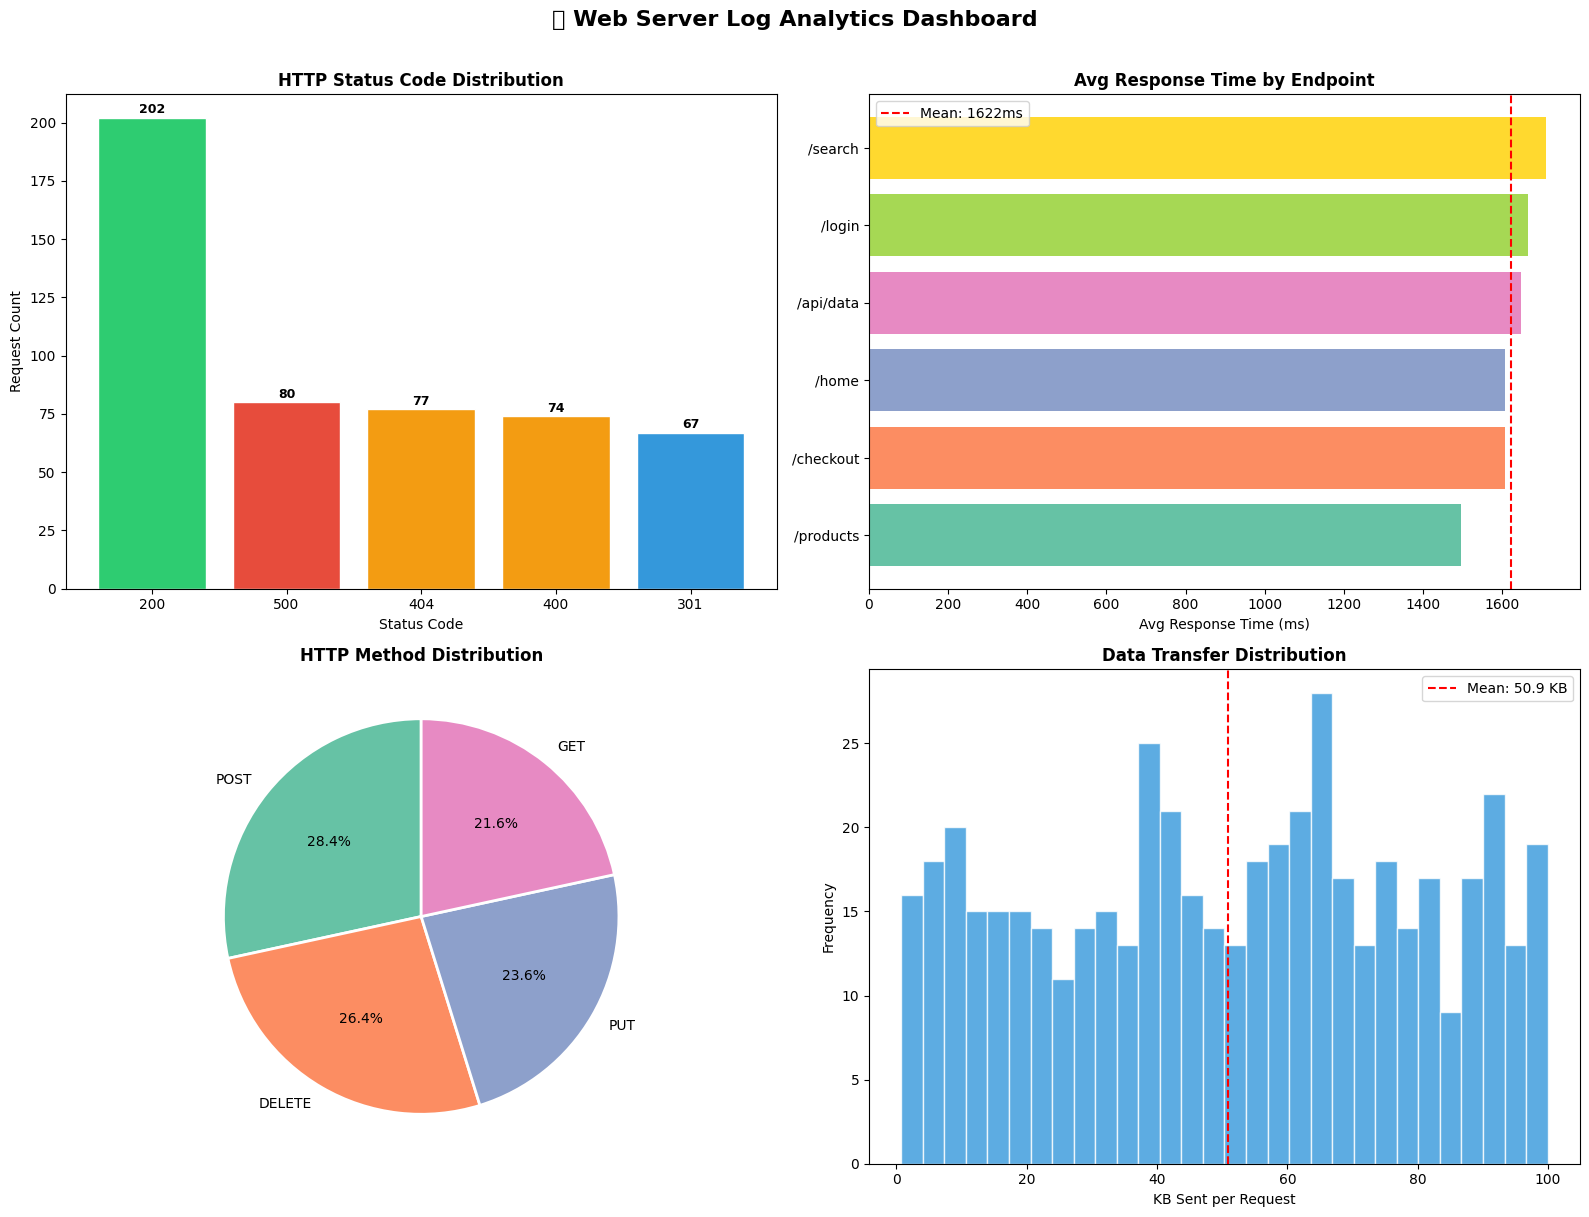

✅ Web Server Analytics Dashboard rendered.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("📡 Web Server Log Analytics Dashboard", fontsize=16, fontweight="bold", y=1.01)
palette = sns.color_palette("Set2")

# ── Plot 1: Status Code Distribution ──────────────────────────
ax1 = axes[0, 0]
status_counts = logs_df["status_code"].value_counts()
colors = ["#2ecc71" if c == 200 else "#e74c3c" if c >= 500
          else "#f39c12" if c >= 400 else "#3498db" for c in status_counts.index]
bars = ax1.bar(status_counts.index.astype(str), status_counts.values, color=colors, edgecolor="white")
ax1.set_title("HTTP Status Code Distribution", fontweight="bold")
ax1.set_xlabel("Status Code")
ax1.set_ylabel("Request Count")
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha="center", fontsize=9, fontweight="bold")

# ── Plot 2: Response Time by Endpoint ─────────────────────────
ax2 = axes[0, 1]
endpoint_perf = logs_df.groupby("endpoint")["response_time_ms"].mean().sort_values(ascending=True)
ax2.barh(endpoint_perf.index, endpoint_perf.values, color=palette[:len(endpoint_perf)])
ax2.set_title("Avg Response Time by Endpoint", fontweight="bold")
ax2.set_xlabel("Avg Response Time (ms)")
ax2.axvline(endpoint_perf.mean(), color="red", linestyle="--", label=f"Mean: {endpoint_perf.mean():.0f}ms")
ax2.legend()

# ── Plot 3: Request Method Distribution ───────────────────────
ax3 = axes[1, 0]
method_counts = logs_df["method"].value_counts()
ax3.pie(method_counts.values, labels=method_counts.index, autopct="%1.1f%%",
        colors=palette[:len(method_counts)], startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2))
ax3.set_title("HTTP Method Distribution", fontweight="bold")

# ── Plot 4: Bytes Sent Distribution ───────────────────────────
ax4 = axes[1, 1]
ax4.hist(logs_df["bytes_sent"] / 1024, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
ax4.set_title("Data Transfer Distribution", fontweight="bold")
ax4.set_xlabel("KB Sent per Request")
ax4.set_ylabel("Frequency")
ax4.axvline(logs_df["bytes_sent"].mean() / 1024, color="red", linestyle="--",
            label=f"Mean: {logs_df['bytes_sent'].mean()/1024:.1f} KB")
ax4.legend()

plt.tight_layout()
plt.savefig("/tmp/dashboard_weblogs.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Web Server Analytics Dashboard rendered.")

### Dashboard 2 — IoT Sensor Analytics

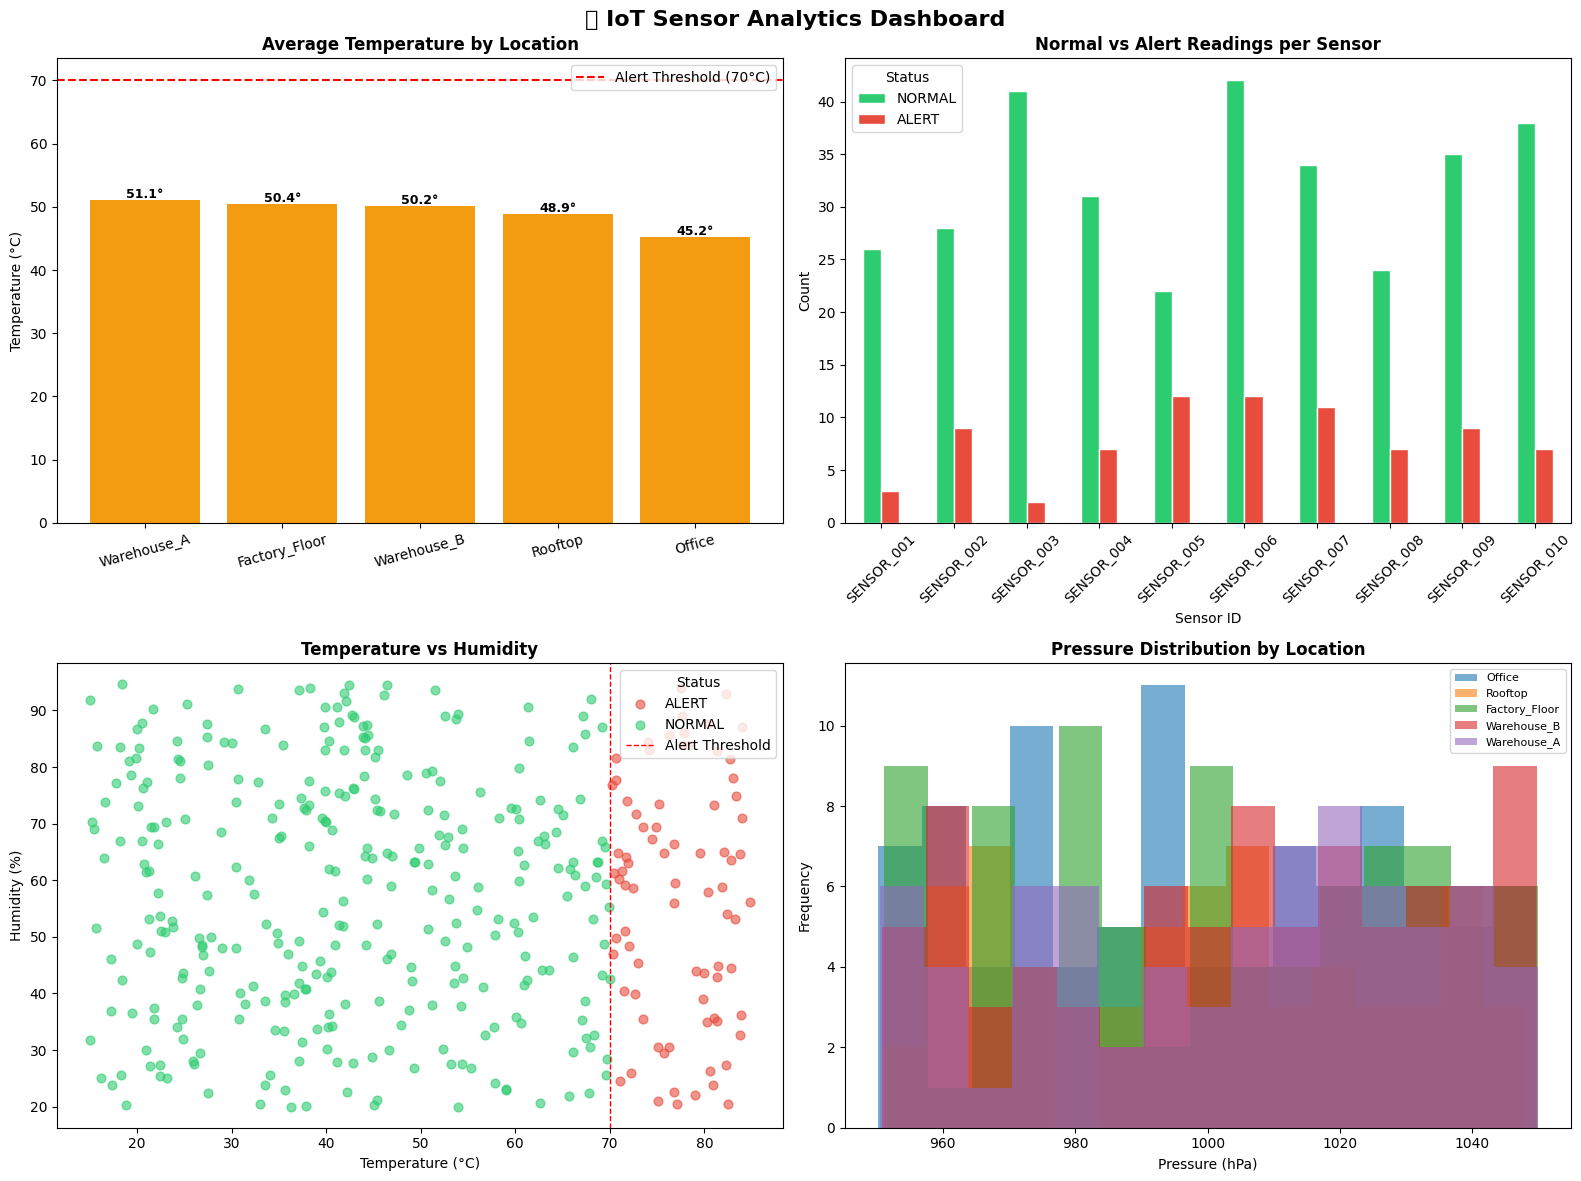

✅ IoT Sensor Analytics Dashboard rendered.


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("🌡️ IoT Sensor Analytics Dashboard", fontsize=16, fontweight="bold")

# ── Plot 1: Temperature by Location ───────────────────────────
ax1 = axes[0, 0]
location_temp = sensors_df.groupby("location")["temperature"].mean().sort_values(ascending=False)
bars = ax1.bar(location_temp.index, location_temp.values,
               color=["#e74c3c" if v > 60 else "#f39c12" if v > 45 else "#2ecc71" for v in location_temp.values])
ax1.set_title("Average Temperature by Location", fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.tick_params(axis="x", rotation=15)
ax1.axhline(70, color="red", linestyle="--", linewidth=1.5, label="Alert Threshold (70°C)")
ax1.legend()
for bar, val in zip(bars, location_temp.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}°", ha="center", fontsize=9, fontweight="bold")

# ── Plot 2: Alert vs Normal per Sensor ────────────────────────
ax2 = axes[0, 1]
alert_df = sensors_df.groupby(["sensor_id", "status"]).size().unstack(fill_value=0)
alert_df[["NORMAL", "ALERT"]].plot(kind="bar", ax=ax2,
    color={"NORMAL": "#2ecc71", "ALERT": "#e74c3c"}, edgecolor="white")
ax2.set_title("Normal vs Alert Readings per Sensor", fontweight="bold")
ax2.set_xlabel("Sensor ID")
ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(title="Status")

# ── Plot 3: Temperature vs Humidity Scatter ────────────────────
ax3 = axes[1, 0]
colors_map = {"NORMAL": "#2ecc71", "ALERT": "#e74c3c"}
for status, group in sensors_df.groupby("status"):
    ax3.scatter(group["temperature"], group["humidity"],
                c=colors_map[status], label=status, alpha=0.6, s=40)
ax3.set_title("Temperature vs Humidity", fontweight="bold")
ax3.set_xlabel("Temperature (°C)")
ax3.set_ylabel("Humidity (%)")
ax3.axvline(70, color="red", linestyle="--", linewidth=1, label="Alert Threshold")
ax3.legend(title="Status")

# ── Plot 4: Pressure Distribution ────────────────────────────
ax4 = axes[1, 1]
for location in sensors_df["location"].unique():
    subset = sensors_df[sensors_df["location"] == location]["pressure"]
    ax4.hist(subset, bins=15, alpha=0.6, label=location)
ax4.set_title("Pressure Distribution by Location", fontweight="bold")
ax4.set_xlabel("Pressure (hPa)")
ax4.set_ylabel("Frequency")
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/dashboard_sensors.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ IoT Sensor Analytics Dashboard rendered.")

### Dashboard 3 — Social Media Analytics

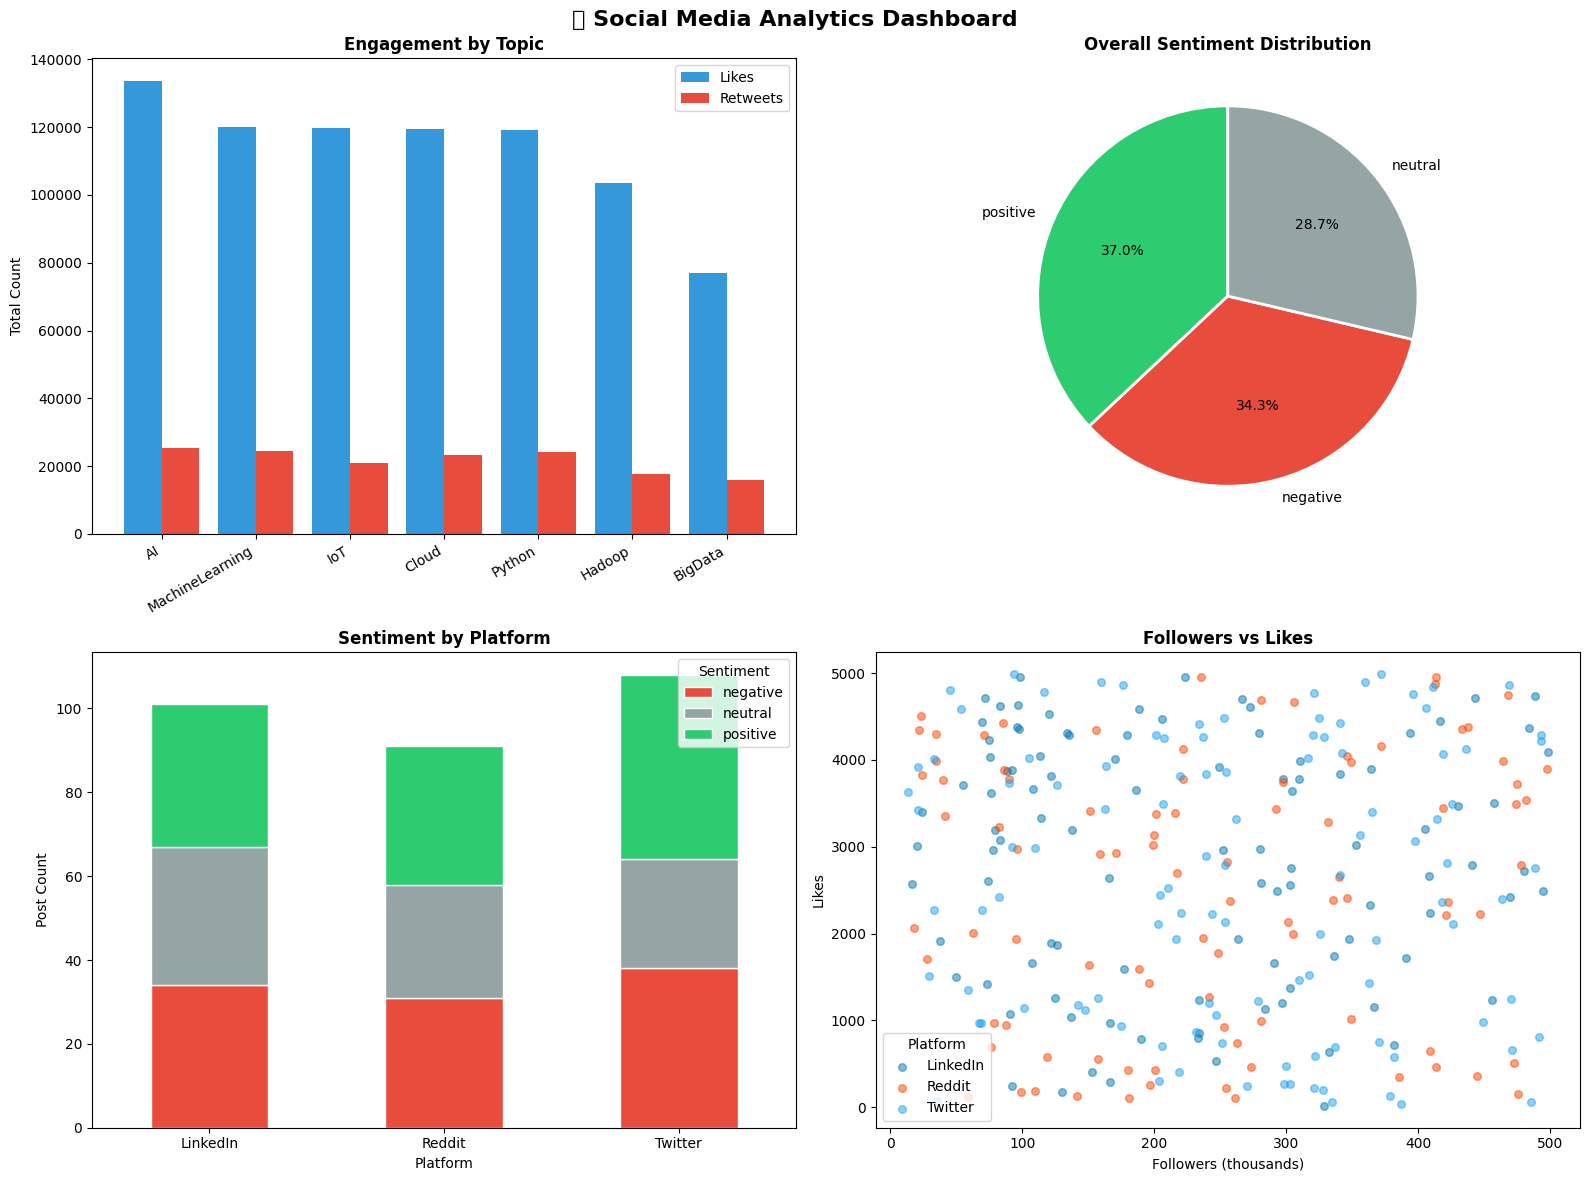

✅ Social Media Analytics Dashboard rendered.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("📱 Social Media Analytics Dashboard", fontsize=16, fontweight="bold")

# ── Plot 1: Engagement by Topic ───────────────────────────────
ax1 = axes[0, 0]
topic_eng = social_df.groupby("topic")[["likes", "retweets"]].sum().sort_values("likes", ascending=False)
x = range(len(topic_eng))
width = 0.4
ax1.bar([i - width/2 for i in x], topic_eng["likes"],     width, label="Likes",    color="#3498db")
ax1.bar([i + width/2 for i in x], topic_eng["retweets"],  width, label="Retweets", color="#e74c3c")
ax1.set_xticks(list(x))
ax1.set_xticklabels(topic_eng.index, rotation=30, ha="right")
ax1.set_title("Engagement by Topic", fontweight="bold")
ax1.set_ylabel("Total Count")
ax1.legend()

# ── Plot 2: Sentiment Distribution ───────────────────────────
ax2 = axes[0, 1]
sentiment_counts = social_df["sentiment"].value_counts()
colors_s = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}
ax2.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        colors=[colors_s[s] for s in sentiment_counts.index],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2))
ax2.set_title("Overall Sentiment Distribution", fontweight="bold")

# ── Plot 3: Platform-wise Post Count ─────────────────────────
ax3 = axes[1, 0]
platform_sentiment = social_df.groupby(["platform", "sentiment"]).size().unstack(fill_value=0)
platform_sentiment.plot(kind="bar", ax=ax3, stacked=True,
    color=[colors_s[c] for c in platform_sentiment.columns], edgecolor="white")
ax3.set_title("Sentiment by Platform", fontweight="bold")
ax3.set_xlabel("Platform")
ax3.set_ylabel("Post Count")
ax3.tick_params(axis="x", rotation=0)
ax3.legend(title="Sentiment")

# ── Plot 4: Followers vs Likes ────────────────────────────────
ax4 = axes[1, 1]
platform_colors = {"Twitter": "#1DA1F2", "Reddit": "#FF4500", "LinkedIn": "#0077B5"}
for platform, group in social_df.groupby("platform"):
    ax4.scatter(group["followers"] / 1000, group["likes"],
                alpha=0.5, s=30, label=platform, color=platform_colors[platform])
ax4.set_title("Followers vs Likes", fontweight="bold")
ax4.set_xlabel("Followers (thousands)")
ax4.set_ylabel("Likes")
ax4.legend(title="Platform")

plt.tight_layout()
plt.savefig("/tmp/dashboard_social.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Social Media Analytics Dashboard rendered.")

### Dashboard 4 — Hive Query Results Summary (Power BI Style)

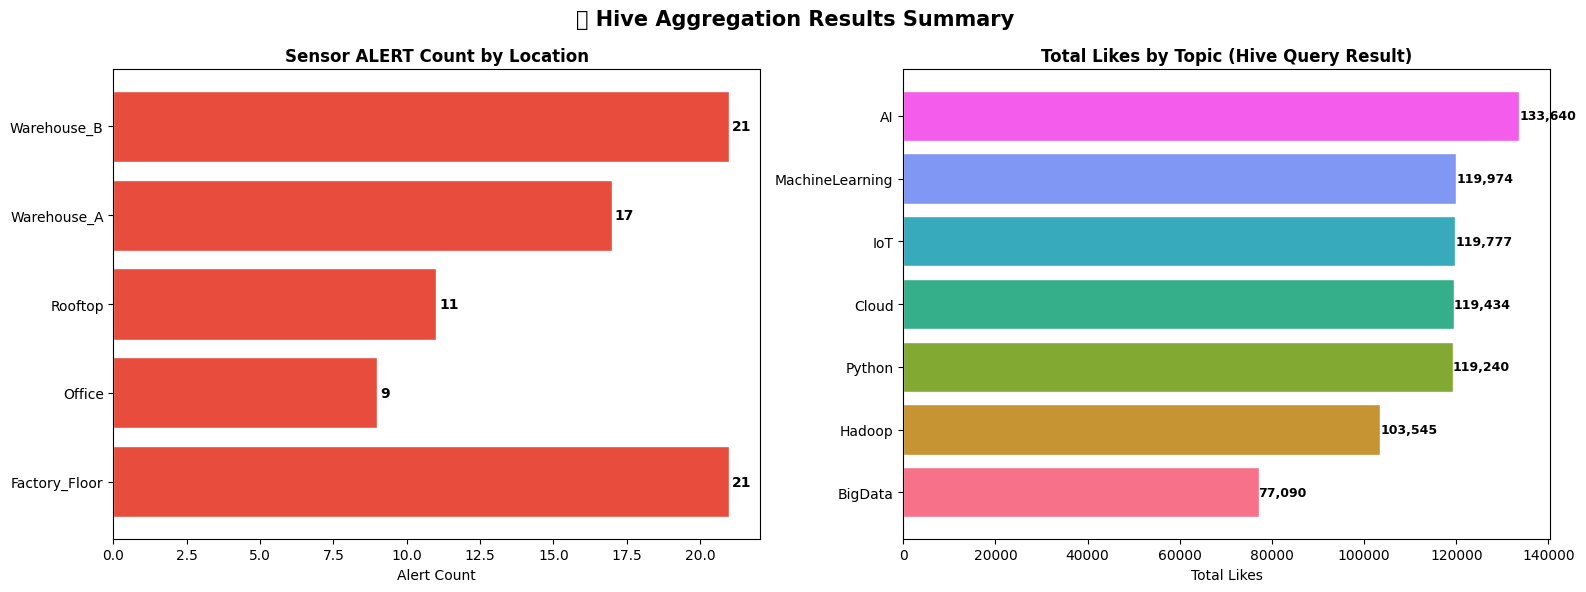

✅ Hive Query Summary Dashboard rendered.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("📊 Hive Aggregation Results Summary", fontsize=15, fontweight="bold")

# ── Plot 1: Alert Count by Sensor Location ────────────────────
ax1 = axes[0]
alert_by_loc = q3_result[q3_result["status"] == "ALERT"].set_index("location")["reading_count"]
ax1.barh(alert_by_loc.index, alert_by_loc.values, color="#e74c3c", edgecolor="white")
ax1.set_title("Sensor ALERT Count by Location", fontweight="bold")
ax1.set_xlabel("Alert Count")
for i, v in enumerate(alert_by_loc.values):
    ax1.text(v + 0.1, i, str(v), va="center", fontweight="bold")

# ── Plot 2: Social Media Likes by Topic ───────────────────────
ax2 = axes[1]
q4_sorted = q4_result.sort_values("total_likes", ascending=True)
colors_bar = sns.color_palette("husl", len(q4_sorted))
ax2.barh(q4_sorted["topic"], q4_sorted["total_likes"], color=colors_bar, edgecolor="white")
ax2.set_title("Total Likes by Topic (Hive Query Result)", fontweight="bold")
ax2.set_xlabel("Total Likes")
for i, v in enumerate(q4_sorted["total_likes"]):
    ax2.text(v + 10, i, f"{v:,}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("/tmp/dashboard_hive_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Hive Query Summary Dashboard rendered.")

## 📋 Step 8: Pipeline Summary Report

In [17]:
total_records  = len(logs_df) + len(sensors_df) + len(social_df)
alert_count    = len(sensors_df[sensors_df["status"] == "ALERT"])
error_count    = len(logs_df[logs_df["status_code"] >= 400])
top_topic      = q4_result.iloc[0]["topic"]
top_endpoint   = q2_result.iloc[0]["endpoint"]

report = f"""
╔══════════════════════════════════════════════════════════════╗
║          BIG DATA PIPELINE — EXECUTION SUMMARY REPORT       ║
╠══════════════════════════════════════════════════════════════╣
║  PIPELINE STAGES                                             ║
║  ├── [1] Data Collection   ✅  3 Sources Connected           ║
║  ├── [2] HDFS Storage      ✅  3 Directories Created         ║
║  ├── [3] Hive Tables       ✅  3 Tables Created & Loaded     ║
║  ├── [4] Hive Queries      ✅  5 SQL Queries Executed        ║
║  └── [5] Visualization     ✅  4 Dashboards Generated        ║
╠══════════════════════════════════════════════════════════════╣
║  DATA STATISTICS                                             ║
║  ├── Total Records Processed : {total_records:,}                        ║
║  ├── Web Log Records         : {len(logs_df):,}                        ║
║  ├── IoT Sensor Records      : {len(sensors_df):,}                        ║
║  └── Social Media Records    : {len(social_df):,}                        ║
╠══════════════════════════════════════════════════════════════╣
║  KEY INSIGHTS                                                ║
║  ├── HTTP Error Requests     : {error_count} ({error_count/len(logs_df)*100:.1f}% error rate)           ║
║  ├── Sensor ALERT Readings   : {alert_count} ({alert_count/len(sensors_df)*100:.1f}% of all readings)   ║
║  ├── Top Social Topic        : {top_topic:<20}             ║
║  └── Slowest Endpoint        : {top_endpoint:<20}             ║
╚══════════════════════════════════════════════════════════════╝
"""
print(report)


╔══════════════════════════════════════════════════════════════╗
║          BIG DATA PIPELINE — EXECUTION SUMMARY REPORT       ║
╠══════════════════════════════════════════════════════════════╣
║  PIPELINE STAGES                                             ║
║  ├── [1] Data Collection   ✅  3 Sources Connected           ║
║  ├── [2] HDFS Storage      ✅  3 Directories Created         ║
║  ├── [3] Hive Tables       ✅  3 Tables Created & Loaded     ║
║  ├── [4] Hive Queries      ✅  5 SQL Queries Executed        ║
║  └── [5] Visualization     ✅  4 Dashboards Generated        ║
╠══════════════════════════════════════════════════════════════╣
║  DATA STATISTICS                                             ║
║  ├── Total Records Processed : 1,200                        ║
║  ├── Web Log Records         : 500                        ║
║  ├── IoT Sensor Records      : 400                        ║
║  └── Social Media Records    : 300                        ║
╠═══════════════════════════════════════

## 🏁 Conclusion

This notebook successfully demonstrates a complete **Big Data Pipeline** using:

| Component | Technology | Purpose |
|---|---|---|
| Data Sources | Python (Faker) | Web logs, IoT sensors, Social media |
| Storage Layer | HDFS (simulated) | Distributed file storage |
| Processing | Hive / SQLite | Table creation, SQL queries |
| Visualization | Matplotlib, Seaborn | Dashboards & charts |

### Key Concepts Demonstrated:
- **Hadoop Architecture**: NameNode/DataNode simulation via directory structure
- **Hive Data Modelling**: DDL with typed columns (TEXT, INTEGER, REAL)
- **HiveQL Queries**: GROUP BY, WHERE, aggregation functions (COUNT, AVG, SUM, MAX)
- **ETL Pipeline**: Extract → Transform → Load → Visualize
- **Multi-source Integration**: Logs + Sensors + Social media in one warehouse